In [9]:
#importing primary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [10]:
#loading the data
df = pd.read_csv('/content/Maryland_Statewide_Vehicle_Crashes.csv')
df.head()

,YEAR,QUARTER,LIGHT_DESC,LIGHT_CODE,COUNTY_DESC,COUNTY_NO,MUNI_DESC,MUNI_CODE,JUNCTION_DESC,JUNCTION_CODE,...,FEET_MILES_FLAG_DESC,FEET_MILES_FLAG,DISTANCE_DIR_FLAG,REFERENCE_NO,REFERENCE_TYPE_CODE,REFERENCE_SUFFIX,REFERENCE_ROAD_NAME,LATITUDE,LONGITUDE,LOCATION
0,2020,Q2,Daylight,1.00,Baltimore,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.277263,-76.503693,POINT (-76.5036932 39.27726285)
1,2020,Q2,NaN,6.02,Baltimore City,24.0,NaN,NaN,Non Intersection,1.0,...,Miles,M,N,NaN,NaN,NaN,NORTH AVE,39.311025,-76.616429,POINT (-76.616429453205 39.311024794431)
2,2020,Q2,Daylight,1.00,Montgomery,15.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.140680,-77.193413,POINT (-77.193412729561 39.140680249069)
3,2017,Q2,Daylight,1.00,Baltimore City,24.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.282928,-76.635215,POINT (-76.6352150952347 39.2829284750108)
4,2020,Q2,Daylight,1.00,Cecil,7.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.611028,-75.951314,POINT (-75.951314 39.611027833333)


In [11]:
#checking the dimension of the data
df.shape

(32115, 56)

In [12]:
#checking variable information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32115 entries, 0 to 32114
Data columns (total 56 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   YEAR                   32115 non-null  int64  
 1   QUARTER                32115 non-null  object 
 2   LIGHT_DESC             30434 non-null  object 
 3   LIGHT_CODE             32114 non-null  float64
 4   COUNTY_DESC            32114 non-null  object 
 5   COUNTY_NO              32114 non-null  float64
 6   MUNI_DESC              0 non-null      float64
 7   MUNI_CODE              18235 non-null  float64
 8   JUNCTION_DESC          21001 non-null  object 
 9   JUNCTION_CODE          22265 non-null  float64
 10  COLLISION_TYPE_DESC    32114 non-null  object 
 11  COLLISION_TYPE_CODE    32114 non-null  float64
 12  SURF_COND_DESC         22228 non-null  object 
 13  SURF_COND_CODE         22265 non-null  float64
 14  LANE_DESC              17797 non-null  object 
 15  LA

In [13]:
#subsetting the data
df_subset = df[['COUNTY_DESC', 'LIGHT_DESC', 'COLLISION_TYPE_DESC', 'WEATHER_DESC','HARM_EVENT_DESC1', 'HARM_EVENT_DESC2', 'RD_COND_DESC', 'REPORT_TYPE' ]]
df_subset.head()

,COUNTY_DESC,LIGHT_DESC,COLLISION_TYPE_DESC,WEATHER_DESC,HARM_EVENT_DESC1,HARM_EVENT_DESC2,RD_COND_DESC,REPORT_TYPE
0,Baltimore,Daylight,Other,Not Applicable,Parked Vehicle,Not Applicable,NaN,Property Damage Crash
1,Baltimore City,NaN,Other,NaN,Other Vehicle,Other Vehicle,No Defects,Injury Crash
2,Montgomery,Daylight,Other,NaN,Pedestrian,Not Applicable,NaN,Injury Crash
3,Baltimore City,Daylight,Single Vehicle,Other,NaN,Not Applicable,NaN,Injury Crash
4,Cecil,Daylight,Same Direction Rear End,NaN,Other Vehicle,Not Applicable,NaN,Property Damage Crash


In [14]:
#changing column names to lower case
df_subset.columns = df_subset.columns.str.lower()

In [15]:
#checking for missing values
df_subset.isna().sum()

,0
county_desc,1
light_desc,1681
collision_type_desc,1
weather_desc,19981
harm_event_desc1,13610
harm_event_desc2,1
rd_cond_desc,9850
report_type,4499


In [16]:
#filling NAs
df_subset['light_desc'] = df_subset['light_desc'].fillna(df_subset['light_desc'].mode()[0])

df_subset['weather_desc'] = df_subset['weather_desc'].fillna(df_subset['weather_desc'].mode()[0])

df_subset['harm_event_desc1'] = df_subset['harm_event_desc1'].fillna(df_subset['harm_event_desc1'].mode()[0])

df_subset['harm_event_desc2'] = df_subset['harm_event_desc2'].fillna(df_subset['harm_event_desc2'].mode()[0])

df_subset['rd_cond_desc'] = df_subset['rd_cond_desc'].fillna(df_subset['rd_cond_desc'].mode()[0])

df_subset['report_type'] = df_subset['report_type'].fillna(df_subset['report_type'].mode()[0])

df_subset['collision_type_desc'] = df_subset['collision_type_desc'].fillna(df_subset['collision_type_desc'].mode()[0])


/tmp/ipykernel_28910/2066599989.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['light_desc'] = df_subset['light_desc'].fillna(df_subset['light_desc'].mode()[0])
/tmp/ipykernel_28910/2066599989.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['weather_desc'] = df_subset['weather_desc'].fillna(df_subset['weather_desc'].mode()[0])
/tmp/ipykernel_28910/2066599989.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

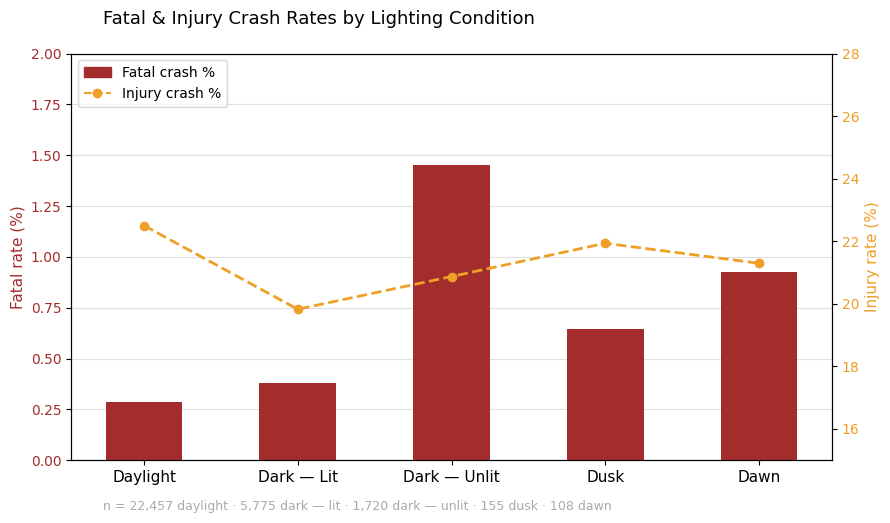

In [42]:




light_order = ['Daylight', 'Dark Lights On', 'Dark No Lights', 'Dusk', 'Dawn']
df_light = df_subset[df_subset['light_desc'].isin(light_order)]

grouped = df_light.groupby('light_desc')['report_type'].value_counts().unstack(fill_value=0)
grouped['total']       = grouped.sum(axis=1)
grouped['fatal_pct']   = grouped['Fatal Crash']    / grouped['total'] * 100
grouped['injury_pct']  = grouped['Injury Crash']   / grouped['total'] * 100
grouped = grouped.reindex(light_order)

labels = ['Daylight', 'Dark — Lit', 'Dark — Unlit', 'Dusk', 'Dawn']
fatal  = grouped['fatal_pct'].values
injury = grouped['injury_pct'].values
x      = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(x, fatal, color='#A32D2D', width=0.5, zorder=3, label='Fatal crash %')
ax1.set_ylabel('Fatal rate (%)', color='#A32D2D', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#A32D2D')
ax1.set_ylim(0, 2.0)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.grid(axis='y', color='#e0e0e0', zorder=0)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()
ax2.plot(x, injury, color='#EF9F27', linestyle='--', marker='o',
         linewidth=2, markersize=6, label='Injury crash %')
ax2.set_ylabel('Injury rate (%)', color='#EF9F27', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#EF9F27')
ax2.set_ylim(15, 28)

fig.suptitle('Fatal & Injury Crash Rates by Lighting Condition', fontsize=13, fontweight='normal', x=0.12, ha='left')


ax1.legend(lines1 + lines2, ['Fatal crash %', 'Injury crash %'], loc='upper left', fontsize=10)

totals = grouped['total'].values
note = ' · '.join(f'{n:,} {l.lower()}' for n, l in zip(totals, labels))
fig.text(0.12, -0.02, f'n = {note}', fontsize=9, color='#aaa')

plt.tight_layout()

plt.show()

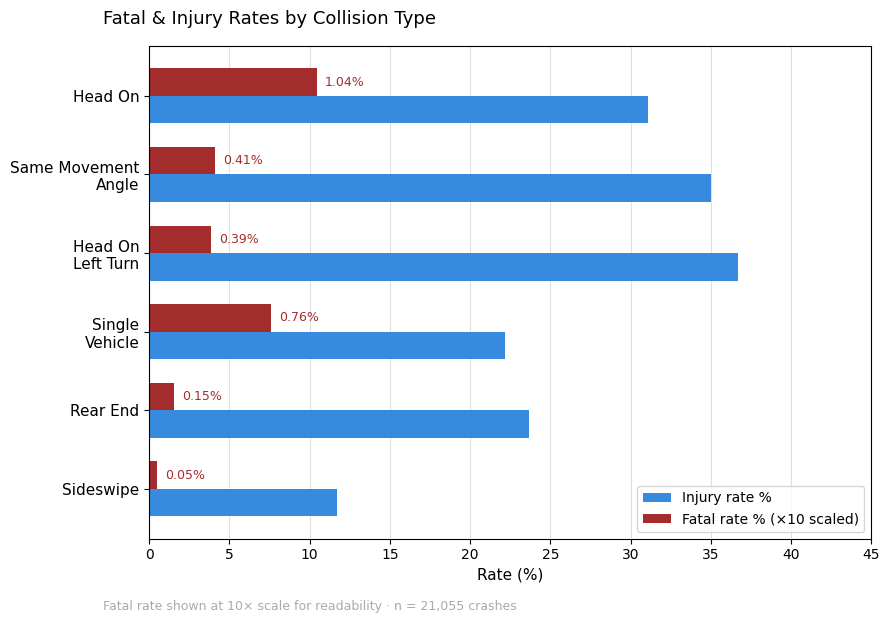

In [43]:


coll_order = ['Head On', 'Same Movement Angle', 'Head On Left Turn',
              'Single Vehicle', 'Same Direction Rear End', 'Same Direction Sideswipe']

df_coll = df_subset[df_subset['collision_type_desc'].isin(coll_order)]

grouped = df_coll.groupby('collision_type_desc')['report_type'].value_counts().unstack(fill_value=0)
grouped['total']      = grouped.sum(axis=1)
grouped['fatal_pct']  = grouped['Fatal Crash']  / grouped['total'] * 100
grouped['injury_pct'] = grouped['Injury Crash'] / grouped['total'] * 100
grouped = grouped.reindex(coll_order)

labels    = ['Head On', 'Same Movement\nAngle', 'Head On\nLeft Turn',
             'Single\nVehicle', 'Rear End', 'Sideswipe']
injury    = grouped['injury_pct'].values
fatal_x10 = grouped['fatal_pct'].values * 10
fatal_raw = grouped['fatal_pct'].values
y         = np.arange(len(labels))
height    = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.barh(y + height / 2, injury,    height=height, color='#378ADD', label='Injury rate %')
bars2 = ax.barh(y - height / 2, fatal_x10, height=height, color='#A32D2D', label='Fatal rate % (×10 scaled)')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Rate (%)', fontsize=11)
ax.set_xlim(0, 45)
ax.grid(axis='x', color='#e0e0e0', zorder=0)
ax.set_axisbelow(True)
ax.invert_yaxis()

for bar, raw in zip(bars2, fatal_raw):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{raw:.2f}%', va='center', fontsize=9, color='#A32D2D')

fig.suptitle('Fatal & Injury Rates by Collision Type', fontsize=13, fontweight='normal', x=0.12, ha='left')


ax.legend(loc='lower right', fontsize=10)
fig.text(0.12, -0.02,
         f'Fatal rate shown at 10× scale for readability · n = {len(df_coll):,} crashes',
         fontsize=9, color='#aaa')

plt.tight_layout()
plt.show()

In [44]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [46]:
# Encode the target: severity as an ordinal number
severity_map = {'Property Damage Crash': 0, 'Injury Crash': 1, 'Fatal Crash': 2}
df_subset['severity'] = df_subset['report_type'].map(severity_map)

# Encode all categorical features with LabelEncoder
features = ['light_desc', 'collision_type_desc', 'weather_desc',
            'harm_event_desc1', 'rd_cond_desc', 'county_desc']

encoder = LabelEncoder()
df_encoded = df[features].copy()
for col in features:
    df_encoded[col] = encoder.fit_transform(df[col].astype(str))

X = df_encoded
y = df_subset['severity']

/tmp/ipykernel_28910/79616813.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subset['severity'] = df_subset['report_type'].map(severity_map)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train two trees
depths = {3: None, 7: None}

print(f"{'Depth':<8} {'Train R²':>10} {'Test R²':>10} {'Train RMSE':>12} {'Test RMSE':>12}")
print("-" * 56)


for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    depths[depth] = model

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    train_r2   = r2_score(y_train, train_pred)
    test_r2    = r2_score(y_test,  test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  test_pred))

    print(f"{depth:<8} {train_r2:>10.4f} {test_r2:>10.4f} {train_rmse:>12.4f} {test_rmse:>12.4f}")



Depth      Train R²    Test R²   Train RMSE    Test RMSE
--------------------------------------------------------
3            0.0611     0.0599       0.4074       0.4066
7            0.1014     0.0923       0.3986       0.3995


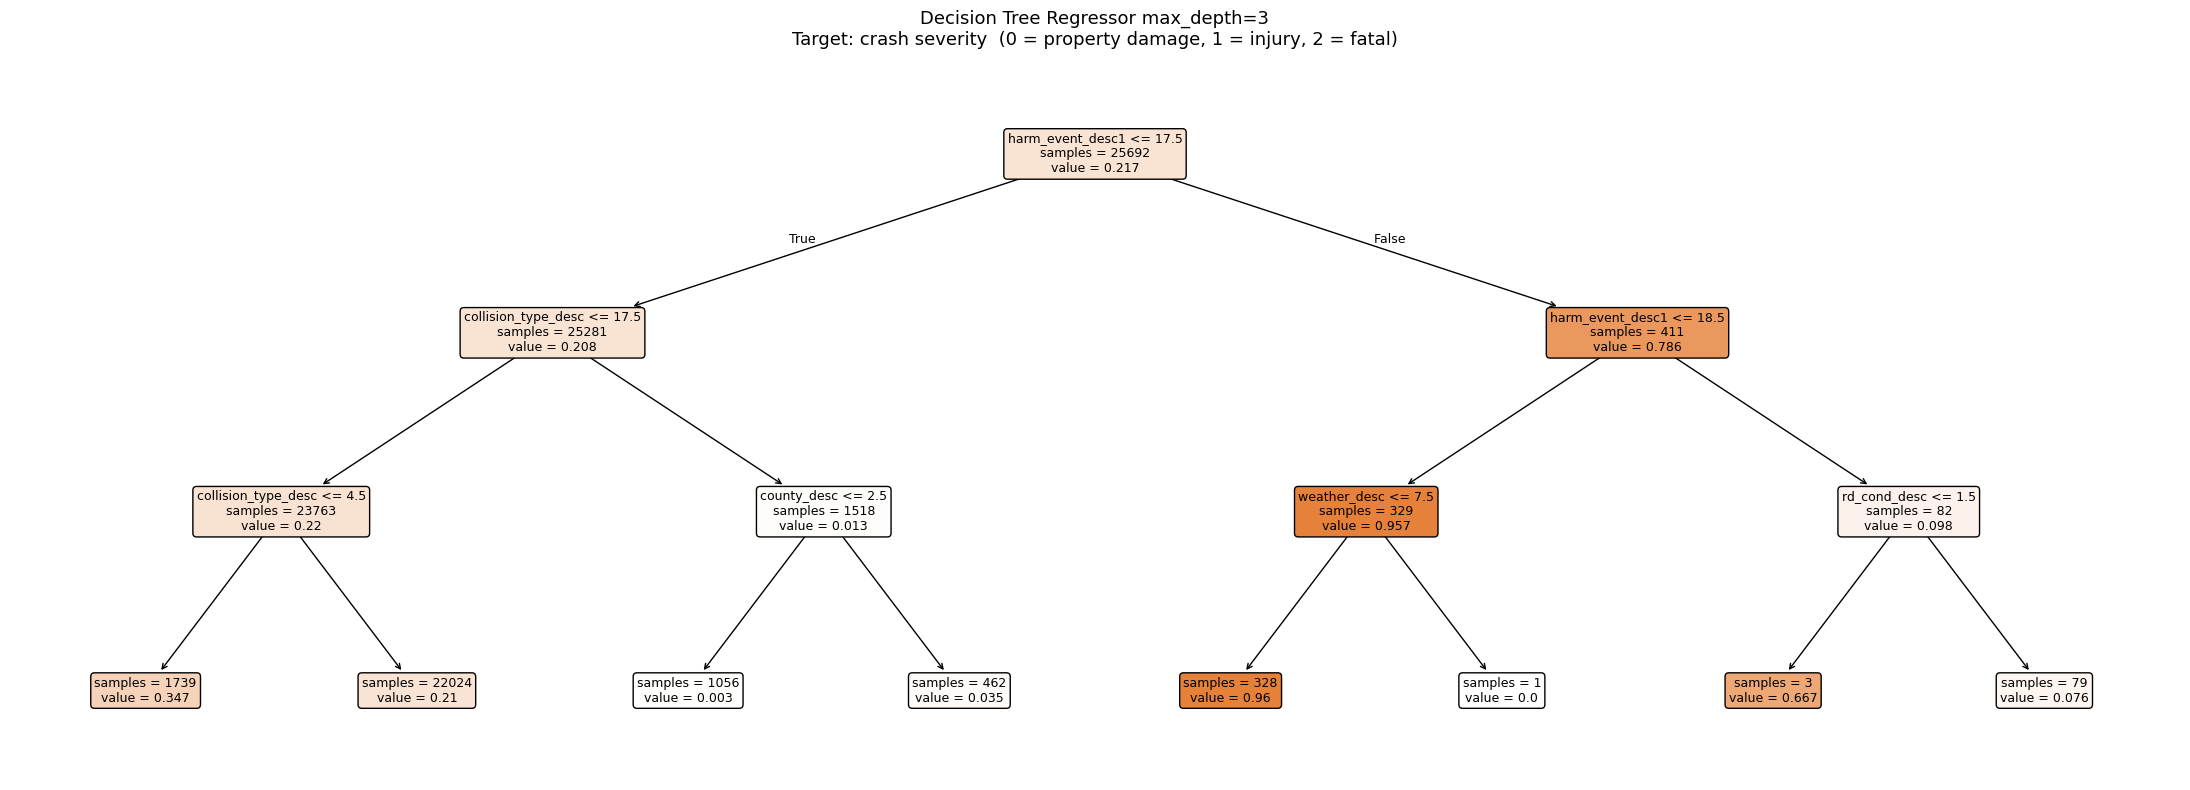

In [60]:
#plottiing depth 3 model
shallow = depths[3]

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    shallow,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,
    precision=3
)
ax.set_title(
    'Decision Tree Regressor max_depth=3\n'
    'Target: crash severity  (0 = property damage, 1 = injury, 2 = fatal)',
    fontsize=13, pad=14
)
plt.tight_layout()
plt.show()

In [54]:
#importing libraries/modules
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [58]:
#Training and testing
rf = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)


train_pred = rf.predict(X_train)
test_pred  = rf.predict(X_test)

# model Evaluation
print(f"Train R²  : {r2_score(y_train, train_pred):.4f}")
print(f"Test  R²  : {r2_score(y_test,  test_pred):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.4f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test,  test_pred)):.4f}")

Train R²  : 0.1086
Test  R²  : 0.1041
Train RMSE: 0.3970
Test  RMSE: 0.3969


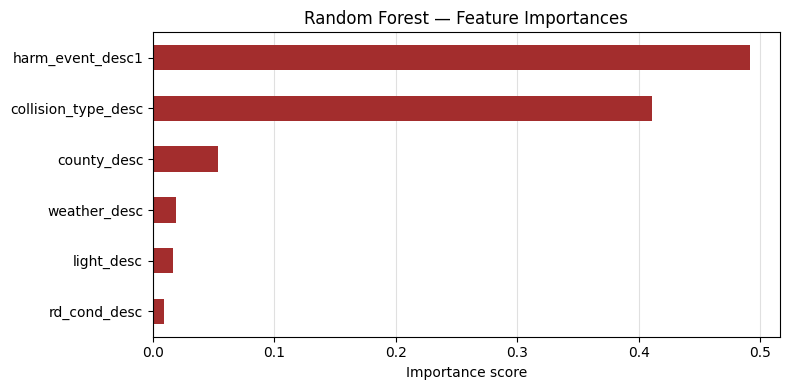

In [53]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind='barh', color='#A32D2D', ax=ax)
ax.set_title('Random Forest — Feature Importances', fontsize=12, fontweight='normal')
ax.set_xlabel('Importance score')
ax.grid(axis='x', color='#e0e0e0')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('rf_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
gb = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=42)

#training and testing
gb.fit(X_train, y_train)


train_pred = gb.predict(X_train)
test_pred  = gb.predict(X_test)

# Model Evaluation
print(f"Train R²  : {r2_score(y_train, train_pred):.4f}")
print(f"Test  R²  : {r2_score(y_test,  test_pred):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_pred)):.4f}")
print(f"Test  RMSE: {np.sqrt(mean_squared_error(y_test,  test_pred)):.4f}")


Train R²  : 0.1282
Test  R²  : 0.1188
Train RMSE: 0.3926
Test  RMSE: 0.3936
